#Problem 3:
#Factor analysis
Use wine datasets place related data and Perform FA

In [2]:
import warnings
warnings.filterwarnings("ignore")


In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

X=pd.read_csv("/places.csv")
print(X.head())

#missing value finding
print("Number of missing value in each columns:",X.isnull().sum().sum())

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity,calculate_kmo
from factor_analyzer.factor_analyzer import calculate_kmo


#standardize data
X_scaled=StandardScaler().fit_transform(X)
print("Standardize data:",X_scaled)

chi_square_values,p_values=calculate_bartlett_sphericity(X_scaled)
print("Bartlett test:",chi_square_values,p_values)

kmo_all,kmo_model=calculate_kmo(X_scaled)
print("kmo test:",kmo_all,kmo_model)



   climate  housing  health  crime  trans  educate  arts  recreate  econ  id
0      521     6200     237    923   4031     2757   996      1405  7633   1
1      575     8138    1656    886   4883     2438  5564      2632  4350   2
2      468     7339     618    970   2531     2560   237       859  5250   3
3      476     7908    1431    610   6883     3399  4655      1617  5864   4
4      659     8393    1853   1483   6558     3026  4496      2612  5727   5
Number of missing value in each columns: 0
Standardize data: [[-0.14700595 -0.90129655 -0.9473398  ... -0.54664636  1.94643332
  -1.72679419]
 [ 0.30066422 -0.08756979  0.46956805 ...  0.97444164 -1.08546728
  -1.71626496]
 [-0.58638594 -0.42305363 -0.56690154 ... -1.22351192 -0.25430354
  -1.70573573]
 ...
 [ 0.01050762  0.01026216 -0.47204161 ... -1.24458649 -0.53505218
   1.70573573]
 [ 0.25921328 -0.55657536 -0.08860777 ... -0.64334144 -1.50659023
   1.71626496]
 [ 0.57424044 -0.19799814 -0.97230294 ... -1.15037077 -0.76777803
 

#interpretation
Bartlett’s test of sphericity
Null hypothesis (Hff): The correlation matrix = Identity (i.e., no correlations between variables).
Alternative (Hff): Correlations exist and the matrix is suitable for FA.
Decision rule:
If p < 0.05, reject Hff → correlations are significant → factor analysis is appropriate. If p ff 0.05,
fail to reject Hff → variables are not sufficiently correlated → FA not appropriate.
Conclusion: Bartlett’s test of sphericity was significant (p < 0.001), rejecting the null hypothesis
that the correlation matrix is an identity matrix. Thus, the data exhibit sufficient correlations for
factor analysis.

#interpretation
KMO (Kaiser–Meyer–Olkin) test
Purpose: Measures sampling adequacy (ratio of partial correlations to total correlations). Scale
interpretation (Kaiser, 1974):
0.90–1.00 = Marvelous
0.80–0.89 = Meritorious
0.70–0.79 = Middling
0.60–0.69 = Mediocre
0.50–0.59 = Miserable
< 0.50 = Unacceptable
Rule of thumb: KMO ff 0.6 is minimum acceptable.
Conclusion: The overall KMO statistic was 0.74, which falls into the “middling” range and
confirms that the sampling adequacy is acceptable for factor analysis.

In [6]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=82b39f12f7ad616a0272bbfd773f882625a9c06e60e2ca24e88d0ad128265105
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [11]:
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import FactorAnalysis

fa=FactorAnalyzer(rotation=None)
X_fa=fa.fit_transform(X_scaled)
print(X_fa)


[[-6.50243187e-01  3.81630000e-01  6.11496634e-01]
 [ 4.88031212e-01  1.33400876e-01 -3.19880356e-01]
 [-9.10341426e-01 -3.94006509e-01 -2.68360967e-01]
 [ 1.53419344e-01 -6.40000136e-01 -1.55391861e-01]
 [ 1.01788540e+00  5.66390146e-01  7.48355441e-02]
 [-8.45487261e-01  7.63773374e-02 -6.26438977e-01]
 [-7.19642697e-01  4.20880252e-01 -3.60996904e-01]
 [-2.93410188e-01  9.08071028e-02 -4.88995329e-01]
 [-8.72860912e-01  5.41007125e-01 -7.52717176e-01]
 [-3.20819518e-01  7.66307242e-01 -1.51406110e-01]
 [ 1.57732964e+00  2.47000656e+00  2.49892982e-01]
 [-4.51680156e-01 -2.53740678e+00  2.77409008e+00]
 [-1.01115426e+00  1.02834177e-01 -9.60650842e-01]
 [-7.22597171e-01  4.71864534e-01 -1.17672915e+00]
 [ 9.06458742e-01 -6.57978709e-01 -5.00396112e-01]
 [-7.02567727e-01  4.04600867e-01 -5.36116508e-01]
 [-5.99679383e-01 -9.45674401e-01  2.65651845e-01]
 [ 1.24324343e-01  1.28873704e+00 -1.10817920e+00]
 [-6.59361273e-01  7.97937755e-01 -4.07143018e-01]
 [ 1.97407673e+00  2.68218919e-

Calculate eigen values and eigen vectors  using FA

In [13]:
eigenvalues,vectors=fa.get_eigenvalues()
print("Eigen values:",eigenvalues)



Eigen values: [3.41323647 1.24257784 1.16511882 0.97635227 0.89379704 0.75035366
 0.6289484  0.49238982 0.31687382 0.12035186]


kaiser criterion method for selecting fa

In [17]:
kaiser_fa_counts=np.sum(eigenvalues>1)
print("Number of selected fa:",kaiser_fa_counts)

Number of selected fa: 3


#interpretation:
Only the first 3 eigenvalues are greater than 1,so we will retain 3 factor for further analysis.

Scree plot method :

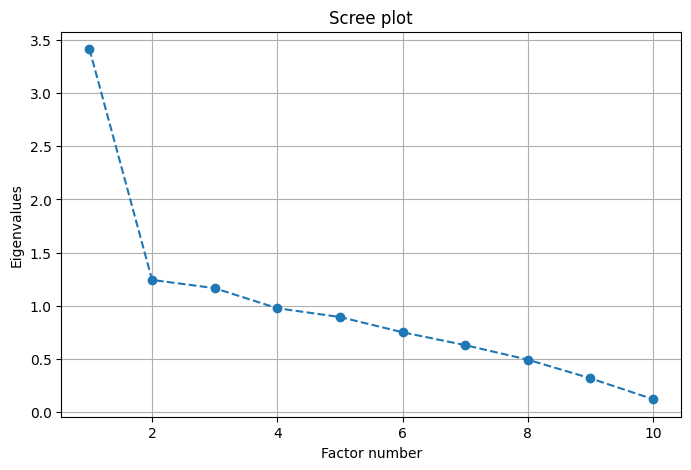

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1,len(eigenvalues)+1), eigenvalues,marker='o',linestyle='--')
plt.xlabel("Factor number")
plt.ylabel("Eigenvalues")
plt.title("Scree plot")
plt.grid()
plt.show()

#Interpretation:
The screeplot shows the eigenvaluesassociated with factor.the elbow point where the curve starts to flatten,indicates the optimal  number of factor to retain.in this case it appears that retaining 3 factors is appropriate ,as the eigenvalues drop significantly after the third factor.

*Modify the factor model with the selected number of factors:


In [29]:
fa1=FactorAnalyzer(n_factors=kaiser_fa_counts,rotation=None)
X_fa1=fa1.fit_transform(X_scaled)
print(X_fa1)
loadings=fa1.loadings_
df_loadings=pd.DataFrame(loadings,index=X.columns,columns=[f'Factor{i+1}' for i in range(kaiser_fa_counts)])
print(df_loadings)


[[-6.50243187e-01  3.81630000e-01  6.11496634e-01]
 [ 4.88031212e-01  1.33400876e-01 -3.19880356e-01]
 [-9.10341426e-01 -3.94006509e-01 -2.68360967e-01]
 [ 1.53419344e-01 -6.40000136e-01 -1.55391861e-01]
 [ 1.01788540e+00  5.66390146e-01  7.48355441e-02]
 [-8.45487261e-01  7.63773374e-02 -6.26438977e-01]
 [-7.19642697e-01  4.20880252e-01 -3.60996904e-01]
 [-2.93410188e-01  9.08071028e-02 -4.88995329e-01]
 [-8.72860912e-01  5.41007125e-01 -7.52717176e-01]
 [-3.20819518e-01  7.66307242e-01 -1.51406110e-01]
 [ 1.57732964e+00  2.47000656e+00  2.49892982e-01]
 [-4.51680156e-01 -2.53740678e+00  2.77409008e+00]
 [-1.01115426e+00  1.02834177e-01 -9.60650842e-01]
 [-7.22597171e-01  4.71864534e-01 -1.17672915e+00]
 [ 9.06458742e-01 -6.57978709e-01 -5.00396112e-01]
 [-7.02567727e-01  4.04600867e-01 -5.36116508e-01]
 [-5.99679383e-01 -9.45674401e-01  2.65651845e-01]
 [ 1.24324343e-01  1.28873704e+00 -1.10817920e+00]
 [-6.59361273e-01  7.97937755e-01 -4.07143018e-01]
 [ 1.97407673e+00  2.68218919e-

#Interpretation
The factor loadings represent the correlation between each variable and the underlying
factor. Higher absolute values indicate a stronger relationship. Here some variables contribute
to multiple factors (i.e. educate,crime,econ,health), which suggests they may be related to more
than one underlying construct. So, We might consider removing these variables or using a different
rotation method to achieve a clearer factor structure

Heatmap

Text(0.5, 1.0, 'Factor loadings heatmap(varimax rotation)')

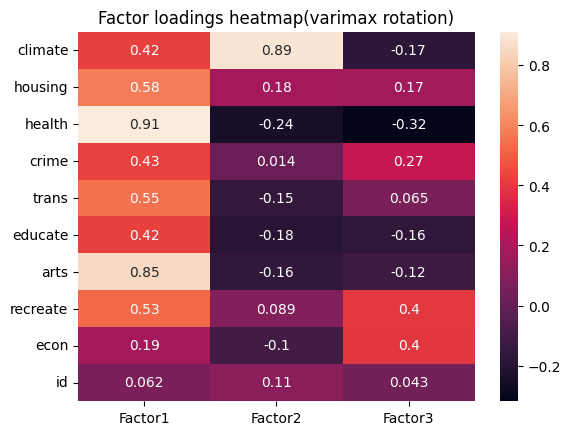

In [30]:
import seaborn as sns
sns.heatmap(df_loadings,annot=True)
plt.title("Factor loadings heatmap(varimax rotation)")

#Interpretation
In this above heatmap, we can see which variables loading high on which factors. This
helps in interpreting the factors. Factor1 highly related to health, educate, arts, trans variables in
the basis of variables Factor1 named as ‘Quality of Life’. Factor2 highly related to crime,housing,
recreate, econ variables in the basis of variables Factor2 named as ‘community well-being’. And
Factor3 highly related to climate so Factor3 named as ‘Environment’.